In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df= pd.read_csv('insurance.csv')

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [7]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<BarContainer object of 1338 artists>

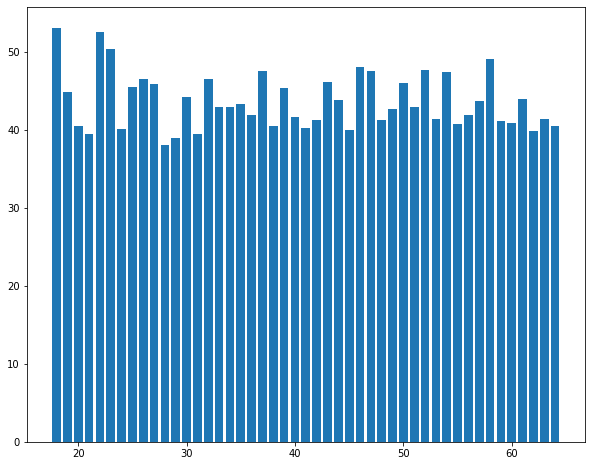

In [8]:
plt.figure(figsize=(10,8))
plt.bar(df['age'],df['bmi'])
# xlable('')

<AxesSubplot:xlabel='age'>

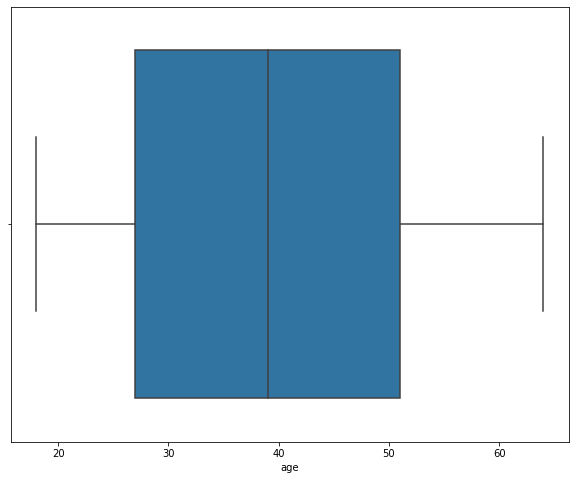

In [9]:
plt.figure(figsize=(10,8))
sns.boxplot(
    x='age',
    y=None,
    hue=None,
    data=df
)

<AxesSubplot:xlabel='bmi'>

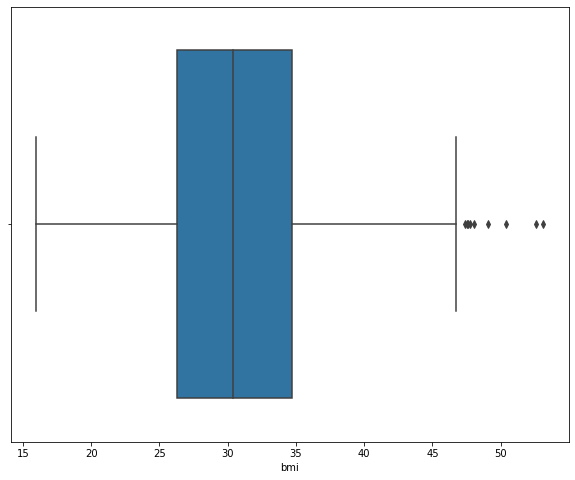

In [10]:
plt.figure(figsize=(10,8))
sns.boxplot(
    x='bmi',
    y=None,
    hue=None,
    data=df
)

<AxesSubplot:xlabel='children'>

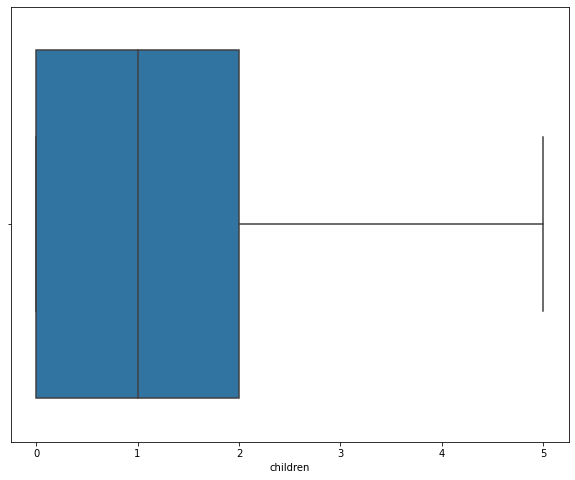

In [11]:
plt.figure(figsize=(10,8))
sns.boxplot(
    x='children',
    y=None,
    hue=None,
    data=df)

<AxesSubplot:xlabel='age', ylabel='bmi'>

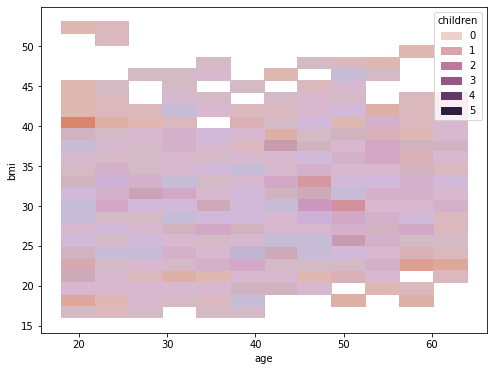

In [12]:
plt.figure(figsize=(8,6))
sns.histplot(data=df,
    
    x='age',
    y='bmi',
    hue='children',
    weights=None,
    stat='count',
    bins='auto'
         
            )

<AxesSubplot:xlabel='smoker', ylabel='count'>

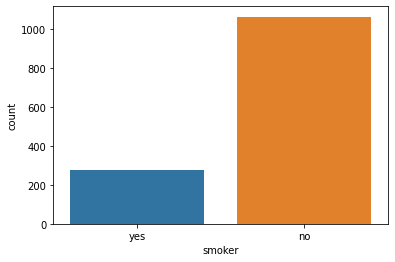

In [13]:
sns.countplot(
     x='smoker',
    y=None,
    hue=None,
    data=df)

In [14]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<AxesSubplot:xlabel='sex', ylabel='count'>

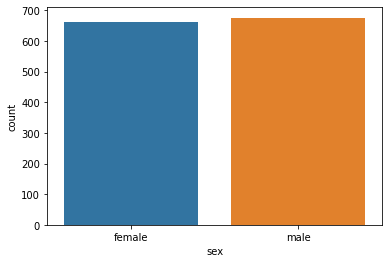

In [15]:
sns.countplot(
     x='sex',
    y=None,
    hue=None,
    data=df 
)


In [16]:
dfg=df.copy()

In [17]:
dfg.drop

<bound method DataFrame.drop of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [18]:
dfg.drop_duplicates(inplace=True)

In [19]:
 dfg= pd.get_dummies(
         dfg,
    prefix=None,
    prefix_sep='_',
    dummy_na=False,
    columns=['region'],
    sparse=False,
    drop_first=False,
    dtype=None)

In [20]:
 dfg['bmi_cat']=pd.cut(   
     dfg['bmi'],
    bins=[0,18.5,24.9,29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [21]:




dfg = pd.get_dummies(dfg, columns=['bmi_cat'], drop_first=True, dtype=int)

In [22]:
dfg['sex'].value_counts()

male      675
female    662
Name: sex, dtype: int64

In [23]:
dfg['sex'] = dfg['sex'].map({'male': 0, 'female': 1})

In [24]:
dfg.rename(columns={
    'sex': 'is_female',
    'smoker': 'is_smoker'
}, inplace=True)

In [25]:
dfg['is_smoker'] = dfg['is_smoker'].map({'no': 0, 'yes': 1})

In [26]:
sdfg = dfg.copy()

In [27]:
x=sdfg.drop('charges', axis=1)


In [28]:
y=sdfg['charges']


In [29]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [30]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [31]:
y_pred = model.predict(x_test)

In [33]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
r2
n = x_test.shape[0]
p = x_test.shape[1]
adjusted_r2 = 1 - ((1- r2) * (n-1) / (n - p - 1))
adjusted_r2

0.7934410193492923